<a href="https://colab.research.google.com/github/Simran1604/Neuromorphic-EuroSAT-SNN/blob/main/Neuromorphic_Eurosat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install snntorch

import torch
import torchvision
import torchvision.transforms as transforms
from snntorch import spikegen
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 2.6 MB/s eta 0:00:00


In [4]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Downloading EuroSAT dataset...")
# Load the dataset twice, once for train transforms, once for test transforms
eurosat_train = torchvision.datasets.EuroSAT(root='./data', download=True, transform=train_transform)
eurosat_test = torchvision.datasets.EuroSAT(root='./data', download=True, transform=test_transform)


print(f"Dataset downloaded successfully! Total images: {len(eurosat_train)+len(eurosat_test)}")

100%|██████████| 94.3M/94.3M [00:00<00:00, 210MB/s]


Dataset downloaded successfully! Total images: 54000


In [5]:
sample_image, sample_label = eurosat_train[0]
print(f"Sample image shape: {sample_image.shape}")

num_steps = 25
spike_data = spikegen.rate(sample_image, num_steps=num_steps)

print(f"Spike data shape: {spike_data.shape}")

Sample image shape: torch.Size([3, 64, 64])
Spike data shape: torch.Size([25, 3, 64, 64])


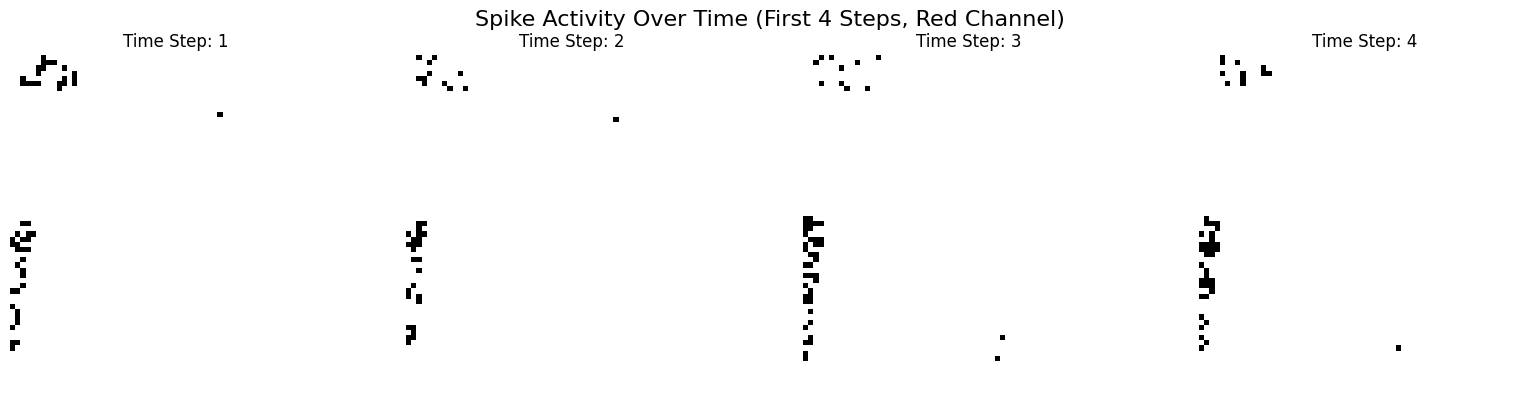

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Spike Activity Over Time (First 4 Steps, Red Channel)", fontsize=16)

for i in range(4):
    spike_frame = spike_data[i, 0].numpy()

    ax = axes[i]
    cax = ax.imshow(spike_frame, cmap='binary')
    ax.set_title(f"Time Step: {i+1}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate

beta = 0.9
spike_grad = surrogate.fast_sigmoid()

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        # First convolution
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        # Second convolution
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        # The "Skip Connection"
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x, mem1, mem2):
        # Path A: Through the convolutions
        out = self.bn1(self.conv1(x))
        spk1, mem1 = self.lif1(out, mem1)

        out = self.bn2(self.conv2(spk1))

        # Path B: The Skip Connection
        shortcut = self.shortcut(x)

        # Combine them!
        out += shortcut
        spk2, mem2 = self.lif2(out, mem2)

        return spk2, mem1, mem2

class CSNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2)
        self.bn1 = nn.BatchNorm2d(32)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.res1 = ResidualBlock(32, 32)

        self.res2 = ResidualBlock(32, 64, stride=2)

        self.fc = nn.Linear(64 * 16 * 16, 10)
        self.lif_fc = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem_r1_1, mem_r1_2 = self.res1.lif1.init_leaky(), self.res1.lif2.init_leaky()
        mem_r2_1, mem_r2_2 = self.res2.lif1.init_leaky(), self.res2.lif2.init_leaky()
        mem_fc = self.lif_fc.init_leaky()

        spk_rec = []
        mem_rec = []

        # Loop over time steps
        for step in range(x.size(0)):
            # Initial Layer
            cur1 = self.bn1(self.conv1(x[step]))
            spk1, mem1 = self.lif1(cur1, mem1)

            # Pass through Residual Blocks
            spk_r1, mem_r1_1, mem_r1_2 = self.res1(spk1, mem_r1_1, mem_r1_2)
            spk_r2, mem_r2_1, mem_r2_2 = self.res2(spk_r1, mem_r2_1, mem_r2_2)

            # Flatten and Classify
            cur_fc = self.fc(spk_r2.view(spk_r2.size(0), -1))
            spk_fc, mem_fc = self.lif_fc(cur_fc, mem_fc)

            spk_rec.append(spk_fc)
            mem_rec.append(mem_fc)

        return torch.stack(spk_rec), torch.stack(mem_rec)

In [9]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")

net = CSNN().to(device)

print(net)

Using device: cpu
CSNN(
  (conv1): Conv2d(3, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lif1): Leaky()
  (res1): ResidualBlock(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (lif1): Leaky()
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (lif2): Leaky()
    (shortcut): Sequential()
  )
  (res2): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (lif1): Leaky()
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

In [10]:
from torch.utils.data import DataLoader, random_split, Subset

train_size = int(0.8 * len(eurosat_train))
test_size = len(eurosat_train) - train_size
indices = torch.randperm(len(eurosat_train)).tolist()

train_dataset = Subset(eurosat_train, indices[:train_size])
test_dataset = Subset(eurosat_test, indices[train_size:])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

In [11]:
import torch.nn as nn
import torch.optim as optim

optimizer = optim.Adam(net.parameters(), lr=1e-3, betas=(0.9, 0.999))

loss_fn = nn.CrossEntropyLoss()

In [13]:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

num_epochs = 30
loss_hist = []
acc_hist = []

print("Starting SNN Training (With Augmentation & Scheduling)...")

for epoch in range(num_epochs):
    net.train()
    train_batch_loss = 0
    correct = 0
    total = 0

    for i, (data, targets) in enumerate(train_loader):
        data = data.to(device)
        targets = targets.to(device)

        spike_data = spikegen.rate(data, num_steps=num_steps)
        spk_rec, mem_rec = net(spike_data)

        mem_rec_sum = mem_rec.sum(dim=0)
        loss = loss_fn(mem_rec_sum, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_batch_loss += loss.item()

        _, predicted = mem_rec_sum.max(1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        if i % 100 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Batch {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

    scheduler.step()

    epoch_acc = 100 * correct / total
    epoch_loss = train_batch_loss / len(train_loader)

    loss_hist.append(epoch_loss)
    acc_hist.append(epoch_acc)

    current_lr = scheduler.get_last_lr()[0]
    print(f"--> Epoch {epoch+1} Completed | LR: {current_lr:.5f} | Average Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%\n")

Starting SNN Training (With Augmentation & Scheduling)...
Epoch 1/30 | Batch 0/675 | Loss: 28.3284
Epoch 1/30 | Batch 100/675 | Loss: 95.7154
Epoch 1/30 | Batch 200/675 | Loss: 28.5318
Epoch 1/30 | Batch 300/675 | Loss: 4.4043
Epoch 1/30 | Batch 400/675 | Loss: 2.4358
Epoch 1/30 | Batch 500/675 | Loss: 2.4609
Epoch 1/30 | Batch 600/675 | Loss: 1.9811
--> Epoch 1 Completed | LR: 0.00100 | Average Loss: 31.7360 | Accuracy: 28.95%

Epoch 2/30 | Batch 0/675 | Loss: 1.9786
Epoch 2/30 | Batch 100/675 | Loss: 1.8459
Epoch 2/30 | Batch 200/675 | Loss: 2.3542
Epoch 2/30 | Batch 300/675 | Loss: 1.8584
Epoch 2/30 | Batch 400/675 | Loss: 2.1371
Epoch 2/30 | Batch 500/675 | Loss: 1.8488
Epoch 2/30 | Batch 600/675 | Loss: 1.6331
--> Epoch 2 Completed | LR: 0.00100 | Average Loss: 2.0978 | Accuracy: 36.13%

Epoch 3/30 | Batch 0/675 | Loss: 2.1890
Epoch 3/30 | Batch 100/675 | Loss: 2.9209
Epoch 3/30 | Batch 200/675 | Loss: 1.8266
Epoch 3/30 | Batch 300/675 | Loss: 1.8798
Epoch 3/30 | Batch 400/675 | L

In [12]:
print("--- Hardware Efficiency Evaluation ---")

net.eval()

data, targets = next(iter(test_loader))
data = data.to(device)

spike_data = spikegen.rate(data, num_steps=num_steps)

with torch.no_grad():
    spk_out, _ = net(spike_data)

total_possible_spikes = spk_out.numel()
actual_spikes = spk_out.sum().item()

firing_rate = actual_spikes / total_possible_spikes

print(f"Total possible computations (Standard Dense ANN): {total_possible_spikes}")
print(f"Actual computations executed (Our Sparse SNN): {actual_spikes}")
print(f"Network Firing Rate: {firing_rate * 100:.2f}% (Lower is better!)\n")


ann_energy = total_possible_spikes * 4.6
snn_energy = actual_spikes * 0.9

print(f"Estimated Energy Cost (Standard ANN): {ann_energy:.2f} pJ")
print(f"Estimated Energy Cost (Our SNN):      {snn_energy:.2f} pJ")

savings = 100 - (snn_energy / ann_energy * 100)
print(f"-> Total Estimated Energy Savings: {savings:.2f}%")

--- Hardware Efficiency Evaluation ---
Total possible computations (Standard Dense ANN): 8000
Actual computations executed (Our Sparse SNN): 0.0
Network Firing Rate: 0.00% (Lower is better!)

Estimated Energy Cost (Standard ANN): 36800.00 pJ
Estimated Energy Cost (Our SNN):      0.00 pJ
-> Total Estimated Energy Savings: 100.00%
